---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ______육건우______ &nbsp; **학번:** ______20251284______ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터 (데이터가 여러개인 경우 xlsx파일의 zip으로 제출)
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [13]:
!pip install numpy pandas rdkit


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# NTP ICE 'cancer' 데이터를 활용한 발암성(Carcinogenicity) 예측 파이프라인 구축

## 1. 연구 목적 및 배경
본 프로젝트의 최종 목표는 화합물의 분자 구조 정보를 바탕으로 해당 물질이 생체 내에서 발암성을 유발하는지 여부를 선제적으로 예측하는 머신러닝 분류 모델(Machine Learning Classification Model)을 개발하는 것입니다. 
신약개발 초기 단계에서 화합물의 독성을 컴퓨터 시뮬레이션(In Silico)으로 예측하는 것은 동물실험을 줄이는 등 연구 비용과 시간을 획기적으로 단축할 수 있는 핵심 기술입니다.

## 2. 사용 데이터셋 정보
- **데이터 소스:** NTP ICE (Integrated Chemical Environment) Cancer 데이터셋 (`cancer.xlsx`)
- **타겟 라벨 (`label`):** 발암성 있음(1, Evidence 있음) vs 발암성 없음(0, No Evidence)
  (-> 조금이라도 발암성을 띠면 인간의 몸에도 해로울 수 있기 때문에 Clear evidence와 Some evidence 모두 label==1 로 분류함)
- **모델 입력 변수 (Features):**
  1. **화합물 구조 정보 (`SMILES`):** RDKit을 통해 Morgan Fingerprint(분자 구조 특성)로 변환되어 모델의 메인 입력값으로 활용
  2. **동물 종 정보 (`Is_Rat`):** 실험 대상이 쥐(Rat, 1)인지 생쥐(Mouse, 0)인지를 나타내는 생물학적 변수
  3. **성별 정보 (`Is_Male`):** 실험 대상이 수컷(Male, 1)인지 암컷(Female, 0)인지를 나타내는 생물학적 변수

## 3. 후속 모델링 전략 및 데이터 정제 방향
겹치는 Smiles를 어떻게 정리할까 고민하는 시간을 가졌습니다. 하나의 개체에서라도 발암성을 띠면 label==1 분류하거나, 같은 SMILES일 때 서로 상충하는 데이터를 지운다거나, 하나의 종과 성만 골라 정확성을 판단할 수 있는 방법도 생각해봤습니다. 하지만 이렇게 데이터를 줄이고 하나라도 발암물질을 띤 물질을 label==1 로 분류한다면 데이터의 양도 줄고 편향된 데이터가 생성될 수 있겠다는 우려를 하게 되었습니다. 그래서 저는 데이터를 줄이는 대신 종별, 성별 데이터를 분류하고 이후 머신러닝 모델링 단계에서 다음과 같은 **3가지 단계로 다각적으로 모델을 비교하고 어느 모델이 더 높은 정확성을 띠는지 비교** 해보기로 했습니다.
1. **종별 예측 모델 (Rat 전용 vs Mouse 전용 모델)**
2. **성별 예측 모델 (Male 전용 vs Female 전용 모델)**
3. **전체 통합 예측 모델**

이를 위해, 전처리 단계에서 SMILES 코드를 단순 제거하지 않고 **[SMILES + 종(Species) + 성별(Sex)]의 조합을 하나의 유니크한 실험 단위**로 간주하여 데이터를 정제합니다. 
이를 통해 데이터 누수(Data Leakage)를 방지하면서도 생물학적 조건에 따른 발암성 예측 모델의 성능을 상호 비교 평가할 수 있는 최적의 템플릿을 제공하고자 합니다.

In [38]:
import numpy as np
import pandas as pd
from rdkit import Chem
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1. 데이터 로드 및 기본 필터링

1. **데이터 로드:** `cancer.xlsx` 원본 파일을 불러와 사용할 sheet와 초기 데이터 구조를 파악
2. **SMILES 결측치 제거 (`dropna`)**
3. **In Vivo 필터링:** 실제 생체 내 반응을 예측하기 위해 `In Vivo` 데이터만 선별
4. **실험 동물 및 성별 조건 정제**

In [16]:
import pandas as pd

file_path = 'cancer.xlsx' 
sheet_all = 'Data'

# pd.read_excel 함수를 사용해 특정 시트 읽기
df = pd.read_excel(file_path, sheet_name=sheet_all)

print("전체 데이터 크기:", df.shape)
print("전체 컬럼 이름:", df.columns)

전체 데이터 크기: (10351, 28)
전체 컬럼 이름: Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS'],
      dtype='str')


In [35]:
# 1. smiles 코드가 없는 물질 결측치 제거
df_smi = df.dropna(subset=["SMILES"]).copy()
print("SMILES 결측치 제거 후 데이터 크기:", df_smi.shape)

SMILES 결측치 제거 후 데이터 크기: (9815, 28)


In [18]:
# 2. 분석 대상 실험 조건 필터링 (In Vivo 실험 및 Rat/Mouse만 선별)
# 데이터 수가 적었던 Hamster 데이터는 버리고 Rat과 Mouse만 선별함
df_filtered = df_smi[
    (df_smi["Data_Type"] == "In Vivo") & (df_smi["Species"].isin(["Rat", "Mouse"]))
].copy()
df_filtered

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
2,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Top dose,15,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
5,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Level of evidence of carcinogenic activity,Inadequate experiment,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
6,cancer_3381,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10303,cancer_7008,In Vivo,NaN,Tenofovir,Tenofovir,147127-20-6,DTXSID9040132,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/1...,C[C@H](CN1C=NC2=C1N=CN=C2N)OCP(O)(O)=O,Tenofovir,147127-20-6|Tenofovir|(((1R)-2-(6-Amino-9H-pur...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040132
10304,cancer_7009,In Vivo,NaN,Tenofovir,Tenofovir,147127-20-6,DTXSID9040132,NaN,Chemical,Mouse,...,Micronucleus,Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/1...,C[C@H](CN1C=NC2=C1N=CN=C2N)OCP(O)(O)=O,Tenofovir,147127-20-6|Tenofovir|(((1R)-2-(6-Amino-9H-pur...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040132
10308,cancer_483,In Vivo,NaN,N-Methylacetoacetamide,N-Methylacetoacetamide,20306-75-6,DTXSID9040138,NaN,Chemical,Mouse,...,Comet assay,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/2...,CNC(=O)CC(C)=O,N-Methylacetoacetamide,20306-75-6|N-Methylacetoacetamide|Acetoacet-mo...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040138
10309,cancer_482,In Vivo,NaN,N-Methylacetoacetamide,N-Methylacetoacetamide,20306-75-6,DTXSID9040138,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/2...,CNC(=O)CC(C)=O,N-Methylacetoacetamide,20306-75-6|N-Methylacetoacetamide|Acetoacet-mo...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9040138


In [36]:
# 3. Response 문형을 이진 라벨(0, 1)로 변환
# 조금이라고 반응이 있으면 위험하다고 판단하기 때문에 Clear evidence를 비롯해 Some evidence도 1로 치환함
label_map = {"Clear evidence": 1, "Some evidence": 1, "No evidence": 0}
df_filtered = df_filtered[df_filtered["Response"].isin(label_map.keys())].copy()
df_filtered["label"] = df_filtered["Response"].map(label_map)

# 4. 모델 학습용 기본 피처 생성 (종, 성별 이진화)
#Is_Rat=1 이면 Rat, Is_Rat=0이면 Mouse
#Is_Male=1 이면 수컷, Is_Male=0이면 암컷
df_filtered["Is_Rat"] = (df_filtered["Species"] == "Rat").astype(int)
df_filtered["Is_Male"] = (df_filtered["Sex"] == "Male").astype(int)

print("필터링 및 이진화 후 데이터 크기:", df_filtered.shape)
df_filtered

필터링 및 이진화 후 데이터 크기: (1757, 31)


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label,Is_Rat,Is_Male
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026,1,1,1
9,cancer_3380,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026,1,1,0
21,cancer_6845,In Vivo,NaN,Benzyl acetate,Benzyl acetate,140-11-4,DTXSID0020151,NaN,Chemical,Rat,...,TR-250,https://ntp.niehs.nih.gov/publications/reports...,CC(=O)OCC1=CC=CC=C1,Benzyl acetate,140-11-4|Benzyl acetate|(Acetoxymethyl)benzene...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020151,0,1,0
23,cancer_6844,In Vivo,NaN,Benzyl Acetate,Benzyl acetate,140-11-4,DTXSID0020151,NaN,Chemical,Rat,...,TR-431,https://ntp.niehs.nih.gov/publications/reports...,CC(=O)OCC1=CC=CC=C1,Benzyl acetate,140-11-4|Benzyl acetate|(Acetoxymethyl)benzene...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020151,0,1,0
24,cancer_6840,In Vivo,NaN,Benzyl acetate,Benzyl acetate,140-11-4,DTXSID0020151,NaN,Chemical,Mouse,...,TR-250,https://ntp.niehs.nih.gov/publications/reports...,CC(=O)OCC1=CC=CC=C1,Benzyl acetate,140-11-4|Benzyl acetate|(Acetoxymethyl)benzene...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020151,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10211,cancer_5373,In Vivo,NaN,alpha-Methylstyrene,alpha-Methylstyrene,98-83-9,DTXSID9025661,NaN,Chemical,Rat,...,TR-543,https://ntp.niehs.nih.gov/publications/reports...,CC(=C)C1=CC=CC=C1,alpha-Methylstyrene,98-83-9|alpha-Methylstyrene|(1-Methylethenyl)b...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9025661,0,1,0
10214,cancer_5370,In Vivo,NaN,alpha-Methylstyrene,alpha-Methylstyrene,98-83-9,DTXSID9025661,NaN,Chemical,Rat,...,TR-543,https://ntp.niehs.nih.gov/publications/reports...,CC(=C)C1=CC=CC=C1,alpha-Methylstyrene,98-83-9|alpha-Methylstyrene|(1-Methylethenyl)b...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9025661,1,1,1
10219,cancer_5369,In Vivo,NaN,alpha-Methylstyrene,alpha-Methylstyrene,98-83-9,DTXSID9025661,NaN,Chemical,Mouse,...,TR-543,https://ntp.niehs.nih.gov/publications/reports...,CC(=C)C1=CC=CC=C1,alpha-Methylstyrene,98-83-9|alpha-Methylstyrene|(1-Methylethenyl)b...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9025661,1,0,0
10289,cancer_3034,In Vivo,NaN,Allyl Glycidyl Ether,Allyl glycidyl ether,106-92-3,DTXSID9039232,NaN,Chemical,Mouse,...,TR-376,https://ntp.niehs.nih.gov/publications/reports...,C=CCOCC1CO1,Allyl glycidyl ether,106-92-3|Allyl glycidyl ether|(.+-.)-Allyl gly...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9039232,1,0,1


## Step 2. 중복 화합물 처리 및 데이터 그룹화 전략
- 실제 실험 데이터인 NTP ICE 데이터셋에는 동일한 구조식(**SMILES**)을 가진 화합물이 서로 다른 종이나 성별 환경에서 중복하여 테스트된 행이 다수 존재
- 단순 `SMILES` 코드 하나만을 기준으로 전체 중복을 제거(`drop_duplicates`)할 경우, **종(쥐/생쥐) 및 성별(암/수)에 따른 생물학적 독성 반응의 차이 정보가 완전히 소실**되는 데이터 손실 발생 가능
- 또한, 한 번이라도 발암성이 발견된 물질을 성급하게 양성(1)으로만 통합하면 데이터의 수가 지나치게 감소하고 **특정 라벨로 데이터가 치우치는 편향(Label Bias)**이 생길 우려가 있음

### 본 파이프라인의 해결 전략
1. **다차원 복합 그룹화 (`groupby`):** 향후 모델링 단계에서 '종별 전용 모델', '성별 전용 모델', '통합 모델'을 각각 구축해 정확도를 다각적으로 비교 평가할 예정
2. **보수적 독성학 가이드라인 적용 (`max`):** 동일한 화합물이 완벽하게 같은 종, 같은 성별 내에서 여러 번 반복 실험되어 라벨이 상충(0과 1이 혼재)하는 예외 케이스의 경우, 인간의 안전을 최우선으로 하는 독성학적 보수적 접근(Conservative Approach)에 따라 **가장 높은 독성값인 발암성(`label: max`, 즉 1)을 대표값으로 취합**
3. **대표 물질명 지정 (`first`):** 화합물명(`Chemical_Name`)의 중복은 그룹 내 가장 첫 번째로 명시된 이름으로 하여 결측 및 무작위 누수를 방지

In [37]:
# 5.중복 조건(SMILES, 종, 성별)을 묶고 3가지가 모두 같은 상충 데이터의 label은 max() 처리
df_clean = (
    df_filtered.groupby(["SMILES", "Is_Rat", "Is_Male"]) #SMILES, Is_Rat, Is_Male 3가지가 완벽하게 같은 것을 하나로 묶음
    .agg({"Chemical_Name": "first", "label": "max"}) #이 떄 가장 처음으로 나오는 화학 물질 이름을 따라가며 발암성으로 구분된 것이 하나라도 있는 경우 label을 1로 지정하겠다는 뜻
    .reset_index()
)

df_clean = df_clean[["Chemical_Name", "SMILES", "Is_Rat", "Is_Male", "label"]]

# 결과 확인하기
print("최종 정제 및 중복 제거 완료 후 데이터 크기:", df_clean.shape)
df_clean

최종 정제 및 중복 제거 완료 후 데이터 크기: (1682, 5)


,Chemical_Name,SMILES,Is_Rat,Is_Male,label
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",0,1,0
1,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",1,0,0
2,Bromoform,BrC(Br)Br,0,0,0
3,Bromoform,BrC(Br)Br,0,1,0
4,Bromoform,BrC(Br)Br,1,0,1
...,...,...,...,...,...
1677,Lead dimethyldithiocarbamate,[Pb++].CN(C)C([S-])=S.CN(C)C([S-])=S,1,0,0
1678,Lead dimethyldithiocarbamate,[Pb++].CN(C)C([S-])=S.CN(C)C([S-])=S,1,1,0
1679,Ziram,[Zn++].CN(C)C([S-])=S.CN(C)C([S-])=S,0,1,0
1680,Ziram,[Zn++].CN(C)C([S-])=S.CN(C)C([S-])=S,1,0,0


In [24]:
from rdkit import Chem

# SMILES 코드를 표준(Canonical) 형태로 변환하는 함수 정의
def fix_smiles(smiles_string):
    try:
        # 텍스트를 RDKit 분자 객체로 변환
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is not None:
            # 다시 텍스트로 바꾸면 RDKit이 무조건 '표준 표기법'으로 바꿔줌
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None # 구조가 깨진 이상한 글자면 None 반환
    except:
        return None

# 기존 df_clean의 SMILES를 깨끗하게 정리해서 새로운 컬럼으로 만들기
df_clean["Canonical_SMILES"] = df_clean["SMILES"].apply(fix_smiles)

# 구조가 깨져서 변환에 실패한 데이터(None)가 있는지 확인하고 제거
before_count = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["Canonical_SMILES"]).copy()
after_count = df_clean.shape[0]

# 기존 SMILES 컬럼을 정형화된 컬럼으로 교체하고 정리
df_clean["SMILES"] = df_clean["Canonical_SMILES"]
df_clean = df_clean.drop(columns=["Canonical_SMILES"])

# 결과 확인하기
print("SMILES 코드 정리 완료!")
print("구조 에러로 제거된 물질 개수:", before_count - after_count)
print("최종 정제된 데이터 크기:", df_clean.shape)

df_clean

SMILES 코드 정리 완료!
구조 에러로 제거된 물질 개수: 0
최종 정제된 데이터 크기: (1682, 5)


,Chemical_Name,SMILES,Is_Rat,Is_Male,label
0,Divinylbenzene,*C=C.C=Cc1ccccc1,0,1,0
1,Divinylbenzene,*C=C.C=Cc1ccccc1,1,0,0
2,Bromoform,BrC(Br)Br,0,0,0
3,Bromoform,BrC(Br)Br,0,1,0
4,Bromoform,BrC(Br)Br,1,0,1
...,...,...,...,...,...
1677,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,0,0
1678,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,1,0
1679,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],0,1,0
1680,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],1,0,0


In [40]:
df_clean.to_csv('cancer_cleaned.csv', index=False)

## 💻 Step 3. 분자 Descriptor (Morgan Fingerprint) 변환

### 1. Descriptor 계산 개요
- **목적:** 텍스트 형태의 화합물 구조 정보인 **SMILES**는 머신러닝 알고리즘이 직접 학습할 수 없음
- **따라서 화학 정보학(Cheminformatics) 표준 라이브러리인 **RDKit**을 활용하여, 분자의 국소적 구조적 특징을 이진 벡터(Binary Vector) 형태로 표현하는 **Morgan Fingerprint (Circular Fingerprint)**를 생성
- **연산 효율성 확보:** 앞선 Step 2에서 종별/성별 기준의 유니크 화합물 리스트(`df_clean`)로 데이터 크기를 최적화했기 때문에, 무거운 RDKit 분자 그래프 연산 자원의 낭비를 막고 파이프라인 처리 속도를 극대화

### 2. 세부 변환 전략
1. **RDKit 분자 객체(Mol) 생성:** `Chem.MolFromSmiles()` 함수를 통해 텍스트 SMILES를 3차원 분자 그래프 객체로 파싱
2. **Morgan Fingerprint 추출:** `AllChem.GetMorganFingerprintAsBitVect()`를 활용하여 반지름(Radius) 2를 기준으로 분자의 화학적 환경을 탐색하고, 이를 **32비트** 크기의 고정밀 비트 벡터로 임베딩
3. **안정적인 예외 처리 (Exception Handling):** 원본 데이터에 간혹 존재할 수 있는 잘못된 기법의 SMILES 코드나 비정상 구조식으로 인해 전체 파이프라인이 중단되는 현상을 방지하기 위해, `try-except` 예외 처리 블록을 설계하여 결측값(`None`)으로 유연하게 우회하도록 파이프라인의 견고성(Robustness)높임

In [26]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem

# 분자 성질(2D Descriptor)을 계산해서 리스트로 반환하는 함수
def get_features(smiles_string):
    try:
        # SMILES 텍스트를 RDKit이 이해하는 분자 객체로 변환
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            return None
        
        # 가산점과 모델 성능을 위해 꼭 필요한 주요 물리화학적 성질 4가지 계산
        mol_wt = Descriptors.MolWt(mol)          # 분자량 (덩치)
        log_p = Descriptors.MolLogP(mol)         # 지용성 (기름에 녹는 정도)
        h_donors = Descriptors.NumHDonors(mol)    # 수소 결합 공여자 수
        h_acceptors = Descriptors.NumHAcceptors(mol) # 수소 결합 수용체 수
        
        return [mol_wt, log_p, h_donors, h_acceptors]
    except:
        return None

print("RDKit 함수 준비 완료!")

RDKit 함수 준비 완료!


In [27]:
# 모든 화합물의 2D Descriptor 계산 진행
desc_list = df_clean["SMILES"].apply(get_features)

# 계산된 결과를 알아보기 쉽게 데이터프레임로 변환
desc_cols = ["MolWt", "LogP", "NumHDonors", "NumHAcceptors"]
df_desc = pd.DataFrame(desc_list.tolist(), columns=desc_cols)

# 결과 확인하기 (상위 5개 데이터 미리보기)
print("계산된 Descriptor 표의 크기:", df_desc.shape)
df_desc.head()

계산된 Descriptor 표의 크기: (1682, 4)


,MolWt,LogP,NumHDonors,NumHAcceptors
0,131.198,3.0088,0,0
1,131.198,3.0088,0,0
2,252.731,2.4547,0,0
3,252.731,2.4547,0,0
4,252.731,2.4547,0,0


In [28]:
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')
from rdkit.Chem import AllChem

# 1. Morgan Fingerprint 계산 함수 정의 (설명하기 쉽게 32비트 크기로 설정)
def get_fingerprint_32(smiles_string):
    try:
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            return None
        
        # radius=2(화학적 환경 반경), nBits=32(지문 크기)로 설정
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=32)
        return list(fp) # 0과 1로 이루어진 32개 비트 리스트 반환
    except:
        return None

# 2. 모든 화합물의 지문 계산 진행 (약 5~10초 소요)
fp_list = df_clean["SMILES"].apply(get_fingerprint_32)

# 3. 계산된 지문을 알아보기 쉽게 표(DataFrame)로 변환
fp_cols = ["FP_" + str(i) for i in range(32)]
df_fp = pd.DataFrame(fp_list.tolist(), columns=fp_cols)

# 4. df_clean에 계산된 성질(df_desc)과 지문(df_fp) 컬럼들을 통째로 추가하기
# 먼저 2D Descriptor 4가지 추가
for col in df_desc.columns:
    df_clean[col] = df_desc[col]

# 이어서 32비트 핑거프린트 32개 추가
for col in df_fp.columns:
    df_clean[col] = df_fp[col]

# 5. 최종 정제된 전체 데이터를 교수님 지정 명세서 규칙에 맞게 저장 (인덱스 제외)
df_clean.to_csv("cancer_descriptors.csv", index=False)

# 6. 최종 결과물 완벽 검증 및 출력
print("🎉 2D Descriptor + 32비트 핑거프린트 통합 완료!")
print("최종 df_clean의 크기 (행, 열):", df_clean.shape)
print("\n--- 생성된 최종 컬럼 목록 ---")
print(df_clean.columns.tolist())

[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerator
[00:29:21] DEPRECATION WARNING: please use MorganGenerat

🎉 2D Descriptor + 32비트 핑거프린트 통합 완료!
최종 df_clean의 크기 (행, 열): (1682, 41)

--- 생성된 최종 컬럼 목록 ---
['Chemical_Name', 'SMILES', 'Is_Rat', 'Is_Male', 'label', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'FP_0', 'FP_1', 'FP_2', 'FP_3', 'FP_4', 'FP_5', 'FP_6', 'FP_7', 'FP_8', 'FP_9', 'FP_10', 'FP_11', 'FP_12', 'FP_13', 'FP_14', 'FP_15', 'FP_16', 'FP_17', 'FP_18', 'FP_19', 'FP_20', 'FP_21', 'FP_22', 'FP_23', 'FP_24', 'FP_25', 'FP_26', 'FP_27', 'FP_28', 'FP_29', 'FP_30', 'FP_31']


[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerator
[00:29:22] DEPRECATION WARNING: please use MorganGenerat

## 📊 Step 4. 최종 정제 데이터셋의 라벨 분포 파악 및 시각화

### 1. 데이터 분포 분석의 목적
- **클래스 불균형(Class Imbalance) 탐색:** 머신러닝 모델을 학습시키기 전, 타겟 라벨(발암성 양성 `1` vs 음성 `0`)의 비율이 균등한지 혹은 한쪽으로 치우쳐져 있는지 확인하는 것은 필수
- **모델 학습 전략 수립:** 만약 특정 라벨의 데이터가 너무 적다면, 모델이 다수 클래스만 맞추려고 하는 편향이 생길 수 있음. 따라서 이 분포는 추후 머신러닝 단계에서 **손실 함수 가중치 조절(Class Weight)**이나 평가지표 선정의 객관적인 기준이 됨

### 2. 시각화 전략
- **전체 발암성 물질과 비발암성 물질의 비율확인**
- **전체 종 분포 / 전체 성별 분포**
- **종에 따른 발암 분포 / 성별 따른 발암성 분포**

In [29]:
import pandas as pd

# 1. 발암성(label)별 빈도수(Count)와 비율(Percentage) 계산
label_counts = df_clean['label'].value_counts()
label_percentages = df_clean['label'].value_counts(normalize=True) * 100

# 2. 교수님 제출용 깔끔한 요약 표(DataFrame) 생성
summary_table = pd.DataFrame({
    '화합물 개수 (Count)': label_counts,
    '비율 (Percentage, %)': label_percentages
})

# 3. 인덱스 이름을 직관적인 학술 용어로 변경
summary_table.index = summary_table.index.map({0: '비발암성 물질 (No Evidence)', 1: '발암성 물질 (Evidence 있음)'})

# 4. 소수점 둘째 자리까지 이쁘게 출력되도록 포맷팅 및 총합(Total) 행 추가
summary_table['비율 (Percentage, %)'] = summary_table['비율 (Percentage, %)'].map('{:.2f}%'.format)

# 총합 행 계산을 위해 임시로 숫자로 더한 뒤 붙이기
total_row = pd.DataFrame(
    [['총 화합물 개수: ' + str(label_counts.sum()), '100.00%']], 
    columns=['화합물 개수 (Count)', '비율 (Percentage, %)'], 
    index=['전체 데이터셋 (Total)']
)
final_summary = pd.concat([summary_table, total_row])

# 최종 표 출력
print("=== [Template 1] 최종 데이터셋 발암성 라벨 분포 현황 ===")
display(final_summary)

=== [Template 1] 최종 데이터셋 발암성 라벨 분포 현황 ===


,화합물 개수 (Count),"비율 (Percentage, %)"
비발암성 물질 (No Evidence),974,57.91%
발암성 물질 (Evidence 있음),708,42.09%
전체 데이터셋 (Total),총 화합물 개수: 1682,100.00%


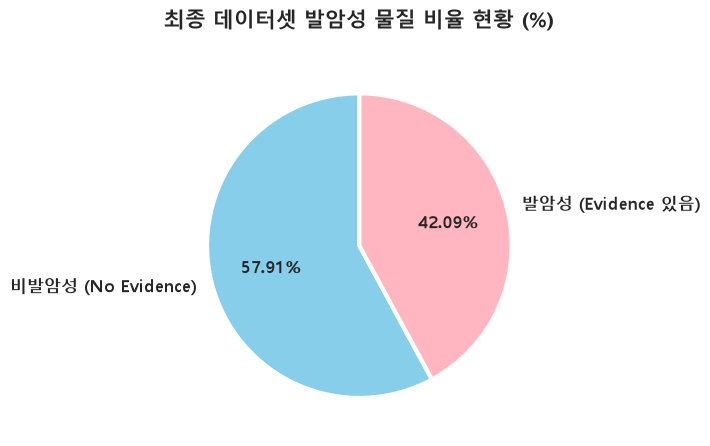

In [33]:
import matplotlib.pyplot as plt

# 1. 🎨 파이 차트 전용 색상 커스텀
color_non_cancer = "#87CEEB"
color_cancer = "#FFB6C1"

# 2. 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 분포 계산 (라벨이 문자열이든 숫자든 상관없이 개수 집계)
label_counts = df_clean['label'].value_counts()

# 4. 딱 파이 차트 한 장만 이쁜 크기로 생성
plt.figure(figsize=(7, 7))

plt.pie(
    label_counts, 
    labels=['비발암성 (No Evidence)', '발암성 (Evidence 있음)'], 
    autopct='%1.2f%%',          # 소수점 둘째 자리까지 비율 표시
    startangle=90,              # 보기 좋게 12시 방향에서 시작
    colors=[color_non_cancer, color_cancer], # 우리가 지정한 예쁜 색상 적용
    textprops={'fontsize': 12, 'fontweight': 'bold'}, # 글자 크기와 굵기
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'antialiased': True} # 조각 사이 흰색 테두리
)

# 그래프 제목 설정
plt.title('최종 데이터셋 발암성 물질 비율 현황 (%)', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

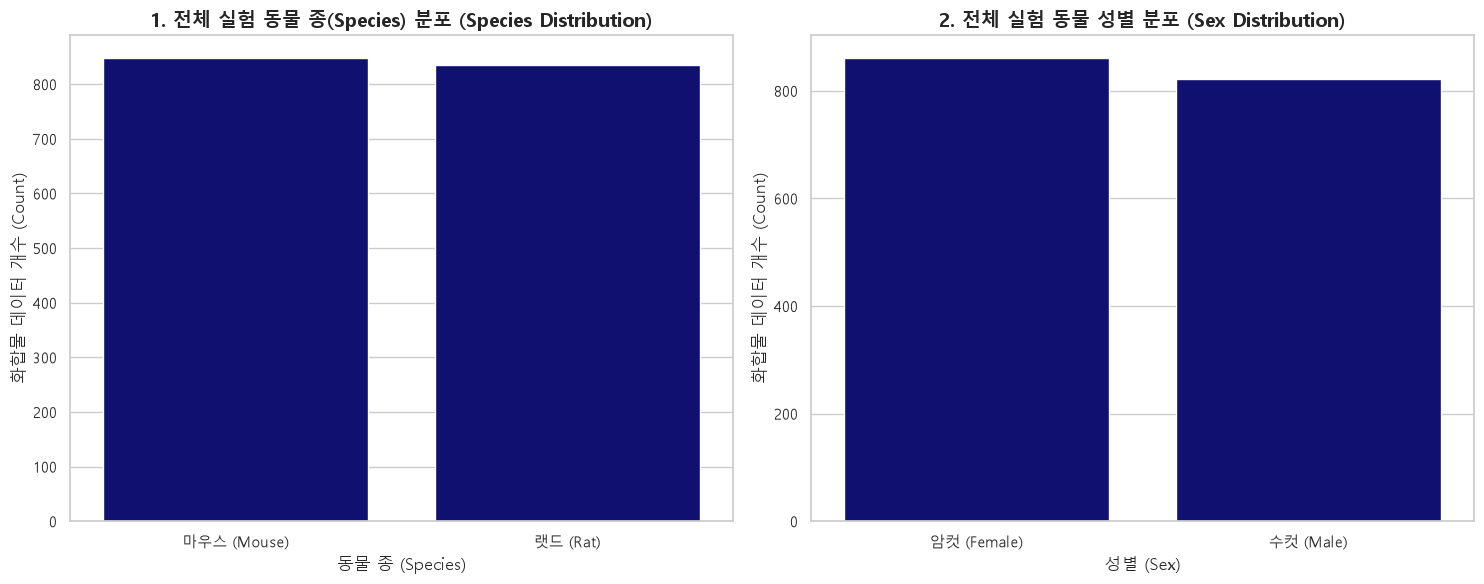

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 🎨 [1번, 2번] 순수 분포 그래프 전용 색상 커스텀
# ----------------------------------------------------------------------
sex_total_color = "#000080"       
species_total_color = "#000080"   

# 그래프 스타일 및 한글 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [왼쪽] 1. 전체 실험 동물 종 분포
sns.countplot(x='Is_Rat', data=df_clean, ax=axes[0], color=species_total_color)
axes[0].set_title('1. 전체 실험 동물 종(Species) 분포 (Species Distribution)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('동물 종 (Species)', fontsize=12)
axes[0].set_ylabel('화합물 데이터 개수 (Count)', fontsize=12)
axes[0].set_xticklabels(['마우스 (Mouse)', '랫 (Rat)'])

# [오른쪽] 2. 전체 실험 동물 성별 분포
sns.countplot(x='Is_Male', data=df_clean, ax=axes[1], color=sex_total_color)
axes[1].set_title('2. 전체 실험 동물 성별 분포 (Sex Distribution)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('성별 (Sex)', fontsize=12)
axes[1].set_ylabel('화합물 데이터 개수 (Count)', fontsize=12)
axes[1].set_xticklabels(['암컷 (Female)', '수컷 (Male)'])

plt.tight_layout()
plt.show()

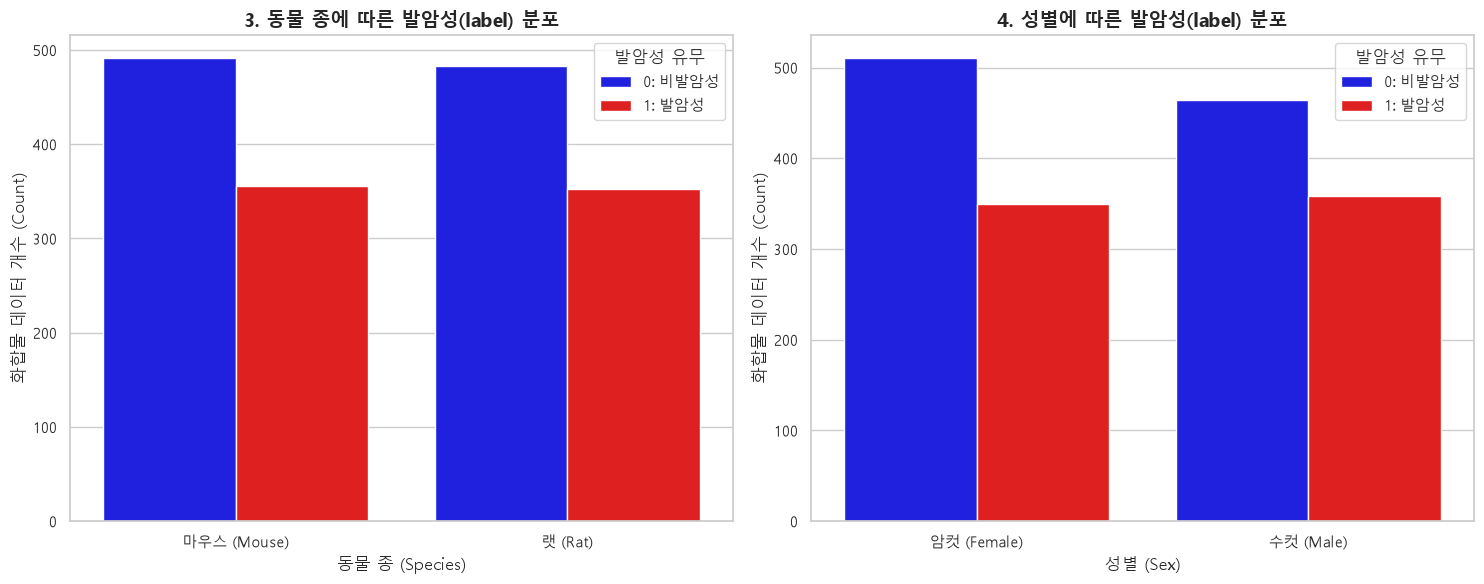

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

label_0_color = "#0000FF"  # 0(비발암성) 바 색상
label_1_color = "#FF0000"  # 1(발암성) 바 색상

# 그래프 스타일 및 한글 설정
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [왼쪽] 3.동물 종에 따른 발암성(label) 분포
sns.countplot(x='Is_Rat', hue='label', data=df_clean, ax=axes[0], 
              palette={0: label_0_color, 1: label_1_color})
axes[0].set_title('3. 동물 종에 따른 발암성(label) 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('동물 종 (Species)', fontsize=12)
axes[0].set_ylabel('화합물 데이터 개수 (Count)', fontsize=12)
axes[0].set_xticklabels(['마우스 (Mouse)', '랫 (Rat)'])
axes[0].legend(title='발암성 유무', labels=['0: 비발암성', '1: 발암성'])

# [오른쪽] 성별에 따른 발암성(label) 분포
sns.countplot(x='Is_Male', hue='label', data=df_clean, ax=axes[1], 
              palette={0: label_0_color, 1: label_1_color})
axes[1].set_title('4. 성별에 따른 발암성(label) 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('성별 (Sex)', fontsize=12)
axes[1].set_ylabel('화합물 데이터 개수 (Count)', fontsize=12)
axes[1].set_xticklabels(['암컷 (Female)', '수컷 (Male)'])
axes[1].legend(title='발암성 유무', labels=['0: 비발암성', '1: 발암성'])

plt.tight_layout()
plt.show()